In [ ]:
%cd ../..

# Results to Latex

In [3]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Optional

import pandas as pd


# ---- helpers ---------------------------------------------------------------

def _safe_float(x: Any) -> Optional[float]:
    """Return float(x) or None if not convertible."""
    try:
        return float(x) if x is not None else None
    except (TypeError, ValueError):
        return None


def _parse_model_args(model_args_str: str) -> Dict[str, str]:
    """
    Parse a 'k=v,k2=v2,...' string into a dict with stripped keys/vals.
    Non 'k=v' chunks are ignored.
    """
    out: Dict[str, str] = {}
    if not model_args_str:
        return out
    for kv in model_args_str.split(","):
        if "=" in kv:
            k, v = kv.split("=", 1)
            out[k.strip()] = v.strip()
    return out


# ---- per-file --------------------------------------------------------------

def extract_eval_row_from_file(file_path: str | Path) -> Optional[Dict[str, Any]]:
    """
    Read one '*_results.json' file and extract a flat row dict.

    Fields produced:
      - file (basename of the JSON file)
      - "edit_score,combine-and-parse"
      - "edit_score_stderr,combine-and-parse"
      - "action_error_rate,combine-and-parse"
      - "action_error_rate_stderr,combine-and-parse"
      - "mae_avg,combine-and-parse"
      - "mae_avg_stderr,combine-and-parse"
      - "prompt" (from configs -> ... -> lmms_eval_specific_kwargs)
      - "use_video_with_segmentations" (same)
      - "total_evaluation_time_seconds" (top level, coerced to float if possible)
      - "max_frames_num" (from parsed config.model_args)
      - "sampling_fps"   (from parsed config.model_args)

    Notes:
      * If the file is unreadable, invalid JSON, or lacks expected blocks, returns None.
      * Automatically picks the (single) task key found under results/configs.

    Parameters
    ----------
    file_path : str | Path

    Returns
    -------
    dict | None
        A single “row” dict, or None if the file cannot be parsed.
    """
    fp = Path(file_path)
    try:
        with fp.open("r") as f:
            data = json.load(f)
    except Exception:
        return None  # unreadable/invalid JSON

    # Extract task blocks (first key under "results" and matching in "configs")
    results_block: Dict[str, Any] = data.get("results", {}) or {}
    task_key: Optional[str] = next(iter(results_block.keys()), None)
    task_obj: Dict[str, Any] = results_block.get(task_key, {}) if task_key else {}

    configs_block: Dict[str, Any] = data.get("configs", {}) or {}
    config_obj: Dict[str, Any] = configs_block.get(task_key, {}) if task_key else {}
    lmms_kwargs: Dict[str, Any] = (config_obj.get("lmms_eval_specific_kwargs") or {}) if isinstance(config_obj, dict) else {}

    total_eval_time = _safe_float(data.get("total_evaluation_time_seconds"))

    model_args_str = ((data.get("config") or {}).get("model_args")) or ""
    parsed_args = _parse_model_args(model_args_str)

    row = {
        "file": fp.name,
        "edit_score,combine-and-parse": task_obj.get("edit_score,combine-and-parse"),
        "edit_score_stderr,combine-and-parse": task_obj.get("edit_score_stderr,combine-and-parse"),
        "action_error_rate,combine-and-parse": task_obj.get("action_error_rate,combine-and-parse"),
        "action_error_rate_stderr,combine-and-parse": task_obj.get("action_error_rate_stderr,combine-and-parse"),
        "mae_avg,combine-and-parse": task_obj.get("mae_avg,combine-and-parse"),
        "mae_avg_stderr,combine-and-parse": task_obj.get("mae_avg_stderr,combine-and-parse"),
        "prompt": lmms_kwargs.get("prompt"),
        "use_video_with_segmentations": lmms_kwargs.get("use_video_with_segmentations"),
        "total_evaluation_time_seconds": total_eval_time,
        "max_frames_num": parsed_args.get("max_frames_num"),
        "sampling_fps": parsed_args.get("sampling_fps"),
    }
    return row


# ---- per-folder (aggregator) ----------------------------------------------

def collect_eval_results(dir_path: str | Path) -> pd.DataFrame:
    """
    Scan a directory for files named '*_results.json' and produce one row per file.

    This mirrors the behavior of the original function, but delegates per-file
    parsing to `extract_eval_row_from_file`.

    Parameters
    ----------
    dir_path : str | Path
        Directory containing the result JSON files.

    Returns
    -------
    pandas.DataFrame
        One row per JSON file with the requested fields.
    """
    dir_path = Path(dir_path)
    rows: List[Dict[str, Any]] = []

    for fp in sorted(dir_path.glob("**/*_results.json")):
        row = extract_eval_row_from_file(fp)
        if row is not None:
            row["rel_path"] = str(fp.relative_to(dir_path))
            row["folder"] = str(fp.parent.relative_to(dir_path))
            rows.append(row)

    df = pd.DataFrame(rows)

    # Optional: enforce a consistent column order
    desired_cols = [
        "file",
        "edit_score,combine-and-parse",
        "edit_score_stderr,combine-and-parse",
        "action_error_rate,combine-and-parse",
        "action_error_rate_stderr,combine-and-parse",
        "mae_avg,combine-and-parse",
        "mae_avg_stderr,combine-and-parse",
        "prompt",
        "use_video_with_segmentations",
        "total_evaluation_time_seconds",
        "max_frames_num",
        "sampling_fps",
    ]
    # Keep any extra columns at the end (if ever added upstream)
    ordered_cols = [c for c in desired_cols if c in df.columns] + [c for c in df.columns if c not in desired_cols]
    return df.reindex(columns=ordered_cols)


In [4]:
import pandas as pd
import re
from typing import Optional

PROMPT_MAP = {
    "single_prediction": "SP",
    "single_motion_and_contact": "SMC",
    "ideal": "Ideal"
}

def _pm(val: Optional[float], err: Optional[float], fmt: str = "{:.2f}") -> str:
    """Return 'val ± err' (both formatted) or '–' if val is missing."""
    if pd.isna(val):
        return "–"
    s = fmt.format(val)
    if pd.isna(err) or (err == 0):
        return s
    return f"{s} ± {fmt.format(err)}"

def _fmt_runtime(seconds: Optional[float]) -> str:
    """Format seconds as H:MM:SS (or '–' if missing)."""
    if pd.isna(seconds):
        return "–"
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(round(seconds % 60))
    return f"{h}:{m:02d}:{s:02d}"

def make_results_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a display DataFrame with columns:
    FPS | Frames | Prompt | ES | AER | MAE | Run time
    (ES/AER/MAE shown as 'mean ± stderr')
    """
    out = pd.DataFrame({
        "_file": df.get("file"),
        "FPS": pd.to_numeric(df.get("sampling_fps"), errors="coerce"),
        "Frames": pd.to_numeric(df.get("max_frames_num"), errors="coerce"),
        "Prompt": df.get("prompt").map(PROMPT_MAP).fillna(df.get("prompt")),
        "ES": [
            _pm(v, e) for v, e in zip(
                df.get("edit_score,combine-and-parse"),
                df.get("edit_score_stderr,combine-and-parse"),
            )
        ],
        "AER": [
            _pm(v, e) for v, e in zip(
                df.get("action_error_rate,combine-and-parse"),
                df.get("action_error_rate_stderr,combine-and-parse"),
            )
        ],
        "MAE": [
            _pm(v, e) for v, e in zip(
                df.get("mae_avg,combine-and-parse"),
                df.get("mae_avg_stderr,combine-and-parse"),
            )
        ],
        "Run time": df.get("total_evaluation_time_seconds").map(_fmt_runtime),
    })

    columns_so_far = ["file", "sampling_fps", "max_frames_num", "prompt",
                      "edit_score,combine-and-parse", "edit_score_stderr,combine-and-parse",
                      "action_error_rate,combine-and-parse", "action_error_rate_stderr,combine-and-parse",
                      "mae_avg,combine-and-parse", "mae_avg_stderr,combine-and-parse",
                      "total_evaluation_time_seconds"
    ]
    columns_remaining = [c for c in df.columns if c not in columns_so_far]
    for c in columns_remaining:
        out[c] = df[c]

    # Sort by window size
    out["Inverse Window Size"] = (out["FPS"] / out["Frames"]).map(lambda x: int(round(x)))

    out = out.sort_values(["Inverse Window Size"], kind="stable", na_position="last").reset_index(drop=True)
    # Rename
    out.rename(columns={"Inverse Window Size": "$1/d$ (rounded)", "FPS": "$f$", "Frames": "$n$"}, inplace=True)
    return out


def _wrap_best(cell: str, rank: int) -> str:
    """
    rank=0 -> best (green), rank=1 -> second-best (blue), otherwise unchanged.
    """
    if rank == 0:
        return r"\cellcolor{green!20}\textbf{" + cell + "}"
    if rank == 1:
        return r"\cellcolor{blue!20}\textbf{" + cell + "}"
    return cell


def apply_best_second_styling(table_df: pd.DataFrame) -> pd.DataFrame:
    """
    Color + bold the best (green) and second-best (blue) for ES/AER/MAE.
    Works directly from table_df where metrics look like '40.27 ± 1.69'.
    Requires `_wrap_best` defined elsewhere.
    """
    styled = table_df.copy()

    def _extract_val(s: str) -> float | None:
        """Extract the numeric value before '±' (or full string if plain number)."""
        if pd.isna(s):
            return None
        m = re.match(r"^\s*([+-]?\d+(?:\.\d+)?)", str(s))
        return float(m.group(1)) if m else None

    metric_specs = [
        ("ES",  True),   # higher is better
        ("AER", False),  # lower is better
        ("MAE", False),  # lower is better
    ]

    for colname, higher_is_better in metric_specs:
        vals = table_df[colname].map(_extract_val)

        # drop NAs but preserve index alignment
        valid = vals.dropna()
        if valid.empty:
            continue

        # sort by metric, respecting higher/lower is better
        sorted_idx = valid.sort_values(ascending=not higher_is_better).index.tolist()

        best_idx = sorted_idx[0]
        second_idx = sorted_idx[1] if len(sorted_idx) > 1 else None

        styled.loc[best_idx, colname] = _wrap_best(styled.loc[best_idx, colname], rank=0)
        if second_idx is not None:
            styled.loc[second_idx, colname] = _wrap_best(styled.loc[second_idx, colname], rank=1)

    return styled



def results_table_to_latex(table_df: pd.DataFrame) -> str:
    """
    Convert to LaTeX with arrows in metric headers.
    Requires: \\usepackage{booktabs} and \\usepackage[table]{xcolor} in your preamble.
    """
    # rename headers with arrows
    renamed = table_df.rename(columns={
        "ES":  "ES $\\uparrow$",
        "AER": "AER $\\downarrow$",
        "MAE": "MAE $\\downarrow$",
    }).drop(columns=["_file"], errors="ignore")

    col_format = "rrlccc r".replace(" ", "")  # 'rrlcccr'
    return renamed.to_latex(index=False, escape=False, column_format=col_format)



In [4]:
path_1 = "./logs/strokerehab_primitives_1/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct"
idf = collect_eval_results(path_1)
path_2 = "./logs/strokerehab_primitives_2/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct"
spdf = collect_eval_results(path_2)
path_3 = "./logs/strokerehab_primitives_3/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct"
smcdf = collect_eval_results(path_3)

In [ ]:
df = pd.concat([idf, spdf], ignore_index=True)
df['max_frames_num'] = df['max_frames_num'].astype(int)
df['sampling_fps'] = df['sampling_fps'].astype(int)

ideal_fn_filter = (
    ((df['sampling_fps'] == 1) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 2)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 2)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 15) & (df['max_frames_num'] == 15)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 15)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 15))
)
df = df[ideal_fn_filter]
tbl = make_results_table(df)
tbl = tbl[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "MAE", "Run time"]].copy()
tbl.drop(columns=["Run time"], inplace=True)
tbl_styled = apply_best_second_styling(tbl)
latex = results_table_to_latex(tbl_styled)
print(latex)

In [ ]:
tbl_spdf = make_results_table(spdf)
tbl_spdf = tbl_spdf[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "MAE", "Run time"]].copy()
tbl_spdf.drop(columns=['Prompt'], inplace=True)
tbl_styled = apply_best_second_styling(tbl_spdf)
latex = results_table_to_latex(tbl_styled)
print(latex)

In [ ]:
df = pd.concat([spdf, smcdf], ignore_index=True)
tbl = make_results_table(df)
tbl = tbl[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "MAE", "Run time"]].copy()
remove_filter = (
    tbl["$1/d$ (rounded)"].isin([0, 1])
)
tbl = tbl[~remove_filter]

tbl_styled = apply_best_second_styling(tbl)
latex = results_table_to_latex(tbl_styled)
print(latex)

## LLMs Ablation

In [5]:
import datetime as dt
import re

def extract_timestamp_from_filename(fname: str) -> dt.datetime | None:
    m = re.match(r"(\d{8}_\d{6})", fname)
    if not m:
        return None
    try:
        return dt.datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
    except ValueError:
        return None


In [ ]:
all_results = collect_eval_results("./logs/strokerehab_primitives_3/")
all_results['date'] = all_results['file'].map(extract_timestamp_from_filename)
all_results['sampling_fps'] = all_results['sampling_fps'].astype(int)
all_results['max_frames_num'] = all_results['max_frames_num'].astype(int)
all_results.sort_values(by=['date', 'folder'], inplace=True)
all_results = all_results[(all_results['sampling_fps'] == 15) & (all_results['max_frames_num'] == 8)]
latest_results = all_results.groupby(['folder']).first()
tbl = make_results_table(latest_results)

tbl['samples_path'] = tbl['rel_path']\
    .apply(lambda s: s.replace("_results.json", "_samples_strokerehab_primitives_3.jsonl"))
tbl['model'] = tbl['rel_path'].apply(lambda s: s.split('/')[0])
def extract_model_and_size(s: str) -> tuple[str, float]:
    try:
        size_start_idx = -1
        size = float(s.split('_')[size_start_idx][:-1].replace('p', '.'))
    except ValueError:
        size_start_idx = -2
        size = float(s.split('_')[size_start_idx][:-1].replace('p', '.'))
    model_family = '_'.join(s.split('_')[0:size_start_idx])
    return model_family, size
tbl[['model_family', 'model_size']] = tbl['model'].apply(
    lambda s: pd.Series(extract_model_and_size(s))
)
tbl.sort_values(by=['model_family', 'model_size'], inplace=True)
tbl.drop(columns=['model_family', 'model_size'], inplace=True)
tbl['model'] = tbl['model'].apply(lambda s: s.replace('_', r'\_'))
tbl['samples_path'] = tbl['rel_path']\
    .apply(lambda s: s.replace("_results.json", "_samples_strokerehab_primitives_3.jsonl"))


In [ ]:
tbl_ = tbl[["_file", "model", "ES", "AER", "MAE", "Run time"]].copy()
tbl_styled = apply_best_second_styling(tbl_)
latex = results_table_to_latex(tbl_styled)
print(latex)

# Further Analysis
RUN THE SECTION ABOVE.

In [6]:
from __future__ import annotations

import json
import gzip
from pathlib import Path
from typing import Iterable, Dict, Any, List

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import math
import html
import io
from typing import List, Dict, Tuple, Optional, Union, Literal

import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont


def _iter_jsonl(path: Path) -> Iterable[Dict[str, Any]]:
    """
    Stream a .jsonl or .jsonl.gz file, yielding parsed JSON objects line by line.
    Skips blank lines; raises on unrecoverable JSON errors.
    """
    opener = gzip.open if path.suffix == ".gz" or path.suffixes[-2:] == [".jsonl", ".gz"] else open
    mode = "rt"  # text mode
    with opener(path, mode, encoding="utf-8") as f:
        for ln, line in enumerate(f, start=1):
            s = line.strip()
            if not s:
                continue
            try:
                yield json.loads(s)
            except json.JSONDecodeError as e:
                raise ValueError(f"JSON decode error in {path} at line {ln}: {e}") from e


def explode_samples_from_jsonl_paths(
    latest_results_table: pd.DataFrame,
    path_col: str = "samples_path",
    log_dir: str | Path = "./logs/strokerehab_primitives_3/",
) -> pd.DataFrame:
    """
    For each JSONL pointed to by `latest_results_table[path_col]`, read every example (one per line)
    and extract: `id`, `target`, and `filtered_resps`.

    Returns a DataFrame that contains all columns from `latest_results_table`
    plus the exploded per-sample fields: [id, target, filtered_resps, edit_score, action_error_rate, mae_avg].

    Notes
    -----
    - `id` is taken from item['doc']['id'] if present, otherwise item['id'].
    - `filtered_resps` is returned as-is (often a string or a list of strings).
    - Supports both .jsonl and .jsonl.gz files.
    """
    if path_col not in latest_results_table.columns:
        raise KeyError(f"`{path_col}` column not found in latest_results_table.")

    rows: List[Dict[str, Any]] = []

    for _, row in latest_results_table.iterrows():
        p = row[path_col]
        if p is None or (isinstance(p, float) and pd.isna(p)):
            continue
        path = Path(log_dir) / p
        if not path.exists():
            raise FileNotFoundError(f"File not found: {path}")

        for item in _iter_jsonl(path):
            doc = item.get("doc", {})
            ex_id = doc.get("id", item.get("id"))

            target = item.get("target")
            filtered_resps = item.get("filtered_resps")
            if isinstance(filtered_resps, list) and len(filtered_resps) == 1:
                filtered_resps = filtered_resps[0]

            rows.append(
                {
                    **row.to_dict(),  # keep all original columns
                    "samples_path": str(path),
                    "id": ex_id,
                    "target": target,
                    "filtered_resps": filtered_resps,
                    "edit_score": item.get("edit_score"),
                    "action_error_rate": item.get("action_error_rate"),
                    "mae_avg": item.get("mae_avg"),
                }
            )

    return pd.DataFrame(rows)




def _parse_segments(seq: str):
    """
    Parse strings like 'idle@0.000;reach@0.917;transport@1.550;...' into
    list of dicts with {'action': str, 't': float}.
    """
    parts = seq.split(";")
    segs = []
    for p in parts:
        if not p.strip():
            continue
        try:
            action, t = p.split("@")
            segs.append({"action": action.strip(), "t": float(t)})
        except ValueError:
            continue
    return segs


def _segments_to_intervals(segs):
    """
    Given [{'action': a, 't': t}, ...] sorted by t, produce intervals
    [{'action': a, 't0': t0, 't1': t1}, ...]
    """
    intervals = []
    for i, s in enumerate(segs):
        t0 = s["t"]
        t1 = segs[i + 1]["t"] if i + 1 < len(segs) else t0
        intervals.append({"action": s["action"], "t0": t0, "t1": t1})
    return intervals


def _to_intervals_up_to_duration(seq: str, duration: float):
    segs = _parse_segments(seq)
    if not segs:
        return []
    ivals = []
    for i, s in enumerate(segs):
        t0 = s["t"]
        t1 = segs[i+1]["t"] if i+1 < len(segs) else duration
        # clip & keep only positive spans
        t0c, t1c = max(0.0, min(t0, duration)), max(0.0, min(t1, duration))
        if t1c > t0c:
            ivals.append({"action": s["action"], "t0": t0c, "t1": t1c})
    return ivals

def row_accuracy(row) -> float:
    tgt_segs = _parse_segments(row["target"])
    if not tgt_segs:
        return np.nan
    duration = tgt_segs[-1]["t"]  # “The last time of the target is the video's duration.”

    tgt = _to_intervals_up_to_duration(row["target"], duration)
    pred = _to_intervals_up_to_duration(row["filtered_resps"], duration)
    if not pred or not tgt or duration <= 0:
        return 0.0

    i = j = 0
    match_time = 0.0
    while i < len(tgt) and j < len(pred):
        a, b = tgt[i], pred[j]
        start = max(a["t0"], b["t0"])
        end   = min(a["t1"], b["t1"])
        if end > start and a["action"] == b["action"]:
            match_time += (end - start)
        # advance whichever interval ends first (both if tie)
        if a["t1"] <= b["t1"]:
            i += 1
        if b["t1"] <= a["t1"]:
            j += 1

    return match_time / duration


# ----------------------------
# Shared helpers
# ----------------------------
_DEFAULT_PALETTE: List[Tuple[int, int, int]] = [
    (230, 25, 75),   # red
    (60, 180, 75),   # green
    (0, 130, 200),   # blue
    (245, 130, 48),  # orange
    (145, 30, 180),  # purple
    (70, 240, 240),  # cyan
    (240, 50, 230),  # magenta
    (210, 245, 60),  # lime
    (250, 190, 190), # pink
    (0, 128, 128),   # teal
    (170, 110, 40),  # brown
    (255, 225, 25),  # yellow
]

def _rgb_hex(rgb: Tuple[int, int, int]) -> str:
    r, g, b = rgb
    return f"#{r:02x}{g:02x}{b:02x}"

def _infer_actions_in_order(label_segments: List[Dict]) -> List[str]:
    seen, order = set(), []
    for s in label_segments:
        a = s["action"]
        if a not in seen:
            seen.add(a)
            order.append(a)
    return order

def _ensure_color_map(actions_in_order: List[str],
                      color_map: Optional[Dict[str, Tuple[int, int, int]]]) -> Dict[str, Tuple[int, int, int]]:
    if color_map is None:
        return {a: _DEFAULT_PALETTE[i % len(_DEFAULT_PALETTE)] for i, a in enumerate(actions_in_order)}
    # validate provided map
    for a in actions_in_order:
        if a not in color_map:
            raise KeyError(f"'{a}' missing from color_map")
        r, g, b = color_map[a]
        for c in (r, g, b):
            if not (isinstance(c, int) and 0 <= c <= 255):
                raise ValueError(f"Invalid RGB value {color_map[a]} for '{a}'")
    return color_map

def plot_bars_for_df(df, color_map=None):
    """
    Draw one plot per ID:
      - Top row: target (ground truth, assumed same across df)
      - Subsequent rows: filtered_resps (one per model)
    """
    if len(df) == 0:
        return
    
    assert df['id'].nunique() == 1, f"Expected 1 id, got: {df['id'].unique()}"

    id_val = df.iloc[0]['id']
    target_segs = _parse_segments(df.iloc[0]["target"])
    target_ints = _segments_to_intervals(target_segs)

    preds = []
    all_ints = target_ints.copy()
    for _, row in df.iterrows():
        pred_segs = _parse_segments(row["filtered_resps"])
        pred_ints = _segments_to_intervals(pred_segs)
        preds.append((row['model'], pred_ints))
        all_ints.extend(pred_ints)

    actions = _infer_actions_in_order(all_ints)
    cmap = _ensure_color_map(actions, color_map)

    nrows = 1 + len(preds)
    bar_height = 0.9  # fill almost all vertical slot

    fig, ax = plt.subplots(figsize=(12, 0.4 * nrows), constrained_layout=True)

    # Plot target
    for iv in target_ints:
        ax.barh(
            y=0, left=iv["t0"], width=iv["t1"] - iv["t0"],
            height=bar_height, color=_rgb_hex(cmap[iv["action"]]), edgecolor="black"
        )

    # Plot preds
    for i, (model, pred_ints) in enumerate(preds, start=1):
        for iv in pred_ints:
            ax.barh(
                y=i, left=iv["t0"], width=iv["t1"] - iv["t0"],
                height=bar_height, color=_rgb_hex(cmap[iv["action"]]), edgecolor="black"
            )

    ax.set_yticks(range(nrows))
    labels = ["target"] + [m.replace('\\', '') for m, _ in preds]
    edit_scores = [""] + [f"(ES={row['edit_score']:.2f})" for _, row in df.iterrows()]
    action_error_rates = [""] + [f"(AER={row['action_error_rate']:.2f})" for _, row in df.iterrows()]
    ax.set_yticklabels([f"{l} {es} {aer}" for l, es, aer in zip(labels, edit_scores, action_error_rates)])
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{id_val}")

    handles = [mpatches.Patch(color=_rgb_hex(cmap[a]), label=a) for a in actions]
    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.01, 1),   # push just outside right edge
        loc="upper left",
        fontsize=8,
        frameon=False
    )
    # fig.subplots_adjust(right=0.8)

    # Key trick: eliminate white space between bars
    ax.set_ylim(-0.5, nrows - 0.5)
    ax.margins(y=0)

    return fig

In [ ]:
df = explode_samples_from_jsonl_paths(tbl, path_col='samples_path')
df.drop(columns=['_file', '$f$', '$n$', 'Prompt', 'ES', 'AER', 'MAE', 'Run time',
       'use_video_with_segmentations', 'rel_path', 'date', '$1/d$ (rounded)',
       'samples_path'], inplace=True)
# df.set_index(['model', 'id'], inplace=True)

# Examining Qwen2.5-VL-32b (SMC, fps=15, n=8)

In [7]:
import json, re
from typing import Any, Dict, Iterable, List, Tuple
import pandas as pd

def samples_to_dataframes(samples: List[Dict[str, Any]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    wanted = ["id","patient","activity","duration_s","target","path_l","path_v",
              "filtered_resps","stroke","edit_score","action_error_rate"]

    def flat_triplets(x: Any) -> Iterable[Tuple[str,str,str]]:
        if isinstance(x, list):
            if len(x)==3 and all(isinstance(x[i], str) for i in range(3)): yield x[0],x[1],x[2]
            else:
                for y in x: yield from flat_triplets(y)

    def split_ans(s: str) -> tuple[str | None, str | None]:
        """Split answers like 'YES <SEP> NO' or 'hi yes yes' into two parts."""
        if not isinstance(s, str):
            return None, None
        parts = [p.strip() for p in s.split("<SEP>")]
        if len(parts) == 2:
            return parts[0], parts[1]
        toks = re.findall(r"\b(yes|no)\b", s.lower())
        if len(toks) >= 2:
            return toks[0].upper(), toks[1].upper()
        if len(toks) == 1:
            return toks[0].upper(), None
        return None, None

    def a2m(a: str | None) -> bool | None:
        a = a.lower().strip()
        if a == "reach" or a == "transport" or a == "reposition":
            return True
        if a == "idle" or a == "stabilize":
            return False
        raise ValueError(f"Unknown motion answer: {a}")

    def a2g(a: str | None) -> bool | None:
        a = a.lower().strip()
        if a == "transport" or a == "stabilize":
            return True
        if a == "idle" or a == "reach" or a == "reposition":
            return False
        raise ValueError(f"Unknown grasp answer: {a}")


    rows, segs = [], []
    for s in samples:
        d = {k: (s.get(k, s.get("doc",{}).get(k))) for k in wanted}
        fr = d.get("filtered_resps")
        d["filtered_resps"] = ";".join(fr) if isinstance(fr, list) else (fr or "")
        d["resps_json"] = json.dumps(s.get("resps", None), ensure_ascii=False)
        if "input" in s: d["prompt_input"] = s["input"]
        rows.append(d)

        sid = d["id"]
        for i,(a,t0,t1) in enumerate(flat_triplets(s.get("resps", []))):
            m,g = split_ans(a)
            try: t0f=float(t0)
            except: t0f=None
            try: t1f=float(t1)
            except: t1f=None
            segs.append({
                "id": sid, "segment_idx": i, "t0": t0f, "t1": t1f,
                "dt": (t1f-t0f) if (t0f is not None and t1f is not None) else None,
                "answer_raw": a,
                "motion_pred": a2m(a), "grasp_pred": a2g(a)
            })

    df_samples, df_resps = pd.DataFrame(rows), pd.DataFrame(segs)
    if not df_samples.empty:
        df_samples["duration_s"] = pd.to_numeric(df_samples["duration_s"], errors="coerce")
        for c in ("edit_score","action_error_rate"):
            if c in df_samples: df_samples[c]=pd.to_numeric(df_samples[c], errors="coerce")
        if "stroke" in df_samples: df_samples["stroke"] = df_samples["stroke"].astype("boolean")
    if not df_resps.empty:
        for c in ("t0","t1","dt"): df_resps[c]=pd.to_numeric(df_resps[c], errors="coerce")
    return df_samples, df_resps

In [8]:
paths = {
    "crop": "logs_qwen2_5_sig_gen_final/20251104_095353_samples_strokerehab_primitives_3.jsonl",
    "crop/cp": "logs/strokerehab_primitives_3/qwen2_5_vl_signal_generator/20251109_002159_samples_strokerehab_primitives_3.jsonl",
    "cp": "logs_qwen2_5_sig_gen_final/20251105_054016_samples_strokerehab_primitives_3.jsonl",
    "baseline": "logs_qwen2_5_sig_gen_final/20251105_082430_samples_strokerehab_primitives_3.jsonl",
}
def log_to_df(logfile):
    with open(logfile, 'r') as f:
        lines = f.readlines()
    import json
    samples = [json.loads(line) for line in lines]
    return samples_to_dataframes(samples)

dfs = {key: log_to_df(value) for key, value in paths.items()}

dfs['crop'][1].head()

,id,segment_idx,t0,t1,dt,answer_raw,motion_pred,grasp_pred
0,S00011_RTT right side1_1,0,0.000,0.533,0.533,idle,False,False
1,S00011_RTT right side1_1,1,0.533,1.067,0.534,idle,False,False
2,S00011_RTT right side1_1,2,1.067,1.600,0.533,transport,True,True
3,S00011_RTT right side1_1,3,1.600,2.133,0.533,transport,True,True
4,S00011_RTT right side1_1,4,2.133,2.667,0.534,transport,True,True


In [9]:
from lmms_eval.tasks.strokerehab.utils_primitives import _get_primitives_score

def get_metrics_for_row(row):
    target = row['target']
    predicted = row['filtered_resps']

    target = [x['action'].lower().strip() for x in _parse_segments(target)]
    predicted = [x['action'].lower().strip() for x in _parse_segments(predicted)]
    score = _get_primitives_score(predicted, target)

    mae_total = sum([score[f'mae_{p}'] for p in ['idle', 'reach', 'transport', 'reposition', 'stabilize']])
    count_total = score['count_truth']

    metrics = {
        'edit_score': score['edit_score'],
        'action_error_rate': score['action_error_rate'],
        'relative_counting_error': mae_total / count_total
    }
    return metrics

In [10]:
key2metrics = {}

for key, (df_samples, _) in dfs.items():
    metrics = df_samples.apply(get_metrics_for_row, axis=1, result_type='expand')
    df_samples[['edit_score', 'action_error_rate', 'relative_counting_error']] = metrics

    metrics = {
        "edit_score": np.mean(df_samples["edit_score"]),
        "edit_score_std":  np.std(df_samples["edit_score"], ddof=1) / np.sqrt(len(df_samples)),
        "action_error_rate":        np.mean(df_samples["action_error_rate"]),
        "action_error_rate_std":         np.std(df_samples["action_error_rate"], ddof=1) / np.sqrt(len(df_samples)),
        "relative_counting_error":        np.mean(df_samples["relative_counting_error"]),
        "relative_counting_error_std":         np.std(df_samples["relative_counting_error"], ddof=1) / np.sqrt(len(df_samples)),
    }
    key2metrics[key] = metrics

In [11]:
def latex_from_key2metrics(key2metrics):
    rows = []
    for k, m in key2metrics.items():
        rows.append({
            "Model": k,
            "ES":  f"{m['edit_score']:.2f} ± {m['edit_score_std']:.2f}",
            "AER": f"{m['action_error_rate']:.2f} ± {m['action_error_rate_std']:.2f}",
            "RCE": f"{m['relative_counting_error']:.2f} ± {m['relative_counting_error_std']:.2f}",
        })
    df = pd.DataFrame(rows)
    return df.to_latex(
        index=False, escape=False,
        column_format="lccc",
        caption="Counting Metrics Comparison"
    )

print(latex_from_key2metrics(key2metrics))

\begin{table}
\caption{Counting Metrics Comparison}
\begin{tabular}{lccc}
\toprule
Model & ES & AER & RCE \\
\midrule
crop & 48.28 ± 1.53 & 0.61 ± 0.04 & 0.62 ± 0.04 \\
crop/cp & 53.18 ± 1.50 & 0.70 ± 0.05 & 0.76 ± 0.05 \\
cp & 48.32 ± 1.61 & 0.73 ± 0.08 & 0.83 ± 0.08 \\
baseline & 46.47 ± 1.61 & 0.66 ± 0.06 & 0.65 ± 0.06 \\
\bottomrule
\end{tabular}
\end{table}



In [12]:
logfile = "logs_qwen2_5_sig_gen_final/20251104_095353_samples_strokerehab_primitives_3.jsonl"

In [13]:
# Read the json
with open(logfile, 'r') as f:
    lines = f.readlines()
import json
samples = [json.loads(line) for line in lines]

In [14]:
import os
from data.utils_strokerehab import DataPaths, PrimitiveLabelUtils

def get_gt_prims(path_l):
    path_l = os.path.join(DataPaths.RAW_LABEL_DIR, path_l)
    prims, times = PrimitiveLabelUtils.convert_labels_to_prims_times(path_l, duplicate_last_prim=True)
    return prims, times

prims, times = get_gt_prims(samples[0]['path_l'])
prims[:5], times[:5]

len(prims), len(times)

(67, 67)

In [15]:
from bisect import bisect_right
import pandas as pd

# Maps per your rule
_MOTION_TRUE = {"transport","reach","reposition"}
_GRASP_TRUE  = {"transport","stabilize"}

def _prim_to_motion(p: str) -> bool: return p in _MOTION_TRUE
def _prim_to_grasp(p: str)  -> bool: return p in _GRASP_TRUE

def add_gt_signals(df_samples: pd.DataFrame,
                   df_resps: pd.DataFrame,
                   get_gt_prims) -> pd.DataFrame:
    """
    Adds columns to df_resps (in place-friendly; returns new DF):
      - prims_window: list[str] primitives overlapping [t0, t1)
      - motion_gt_middle, grasp_gt_middle: bool at middle time
      - motion_gt_window, grasp_gt_window: nullable bool over window (pd.NA if mixed)
    """
    out = df_resps.copy()

    # Fast lookup per id
    dur_by_id   = df_samples.set_index("id")["duration_s"].to_dict()
    pathl_by_id = df_samples.set_index("id")["path_l"].to_dict()

    # Storage
    prims_win, m_mid, g_mid, m_win, g_win = [], [], [], [], []

    for rid, row in out.iterrows():
        sid = row["id"]
        t0, t1 = row["t0"], row["t1"]

        prims, times = get_gt_prims(pathl_by_id[sid])  # times sorted

        T_end = float(dur_by_id.get(sid, times[-1]))
        # Close the last interval with video end
        seg_starts = list(times)
        seg_ends   = seg_starts[1:] + [T_end]

        # --- middle-time primitive ---
        tm = 0.5*(t0 + t1)
        i_mid = max(0, min(len(seg_starts)-1, bisect_right(seg_starts, tm) - 1))
        p_mid = prims[i_mid]
        m_mid.append(_prim_to_motion(p_mid))
        g_mid.append(_prim_to_grasp(p_mid))

        # --- window primitives (overlap with [t0, t1)) ---
        i = max(0, bisect_right(seg_starts, t0) - 1)
        seen, seq = set(), []
        while i < len(seg_starts) and seg_starts[i] < t1:
            s_i, e_i, p_i = seg_starts[i], seg_ends[i], prims[i]
            if max(s_i, t0) < min(e_i, t1):  # overlap
                if p_i not in seen:
                    seen.add(p_i); seq.append(p_i)
            i += 1

        prims_win.append(seq)

        # Window booleans (nullable): all True -> True, all False -> False, else NA
        mv = [_prim_to_motion(p) for p in seq]
        gv = [_prim_to_grasp(p)  for p in seq]

        def all_or_na(vals):
            if not vals: return pd.NA
            if all(vals): return True
            if not any(vals): return False
            return pd.NA

        m_win.append(all_or_na(mv))
        g_win.append(all_or_na(gv))

    out["prims_window"]      = prims_win
    out["motion_gt_middle"]  = pd.Series(m_mid, dtype="boolean")
    out["grasp_gt_middle"]   = pd.Series(g_mid, dtype="boolean")
    out["motion_gt_window"]  = pd.Series(m_win, dtype="boolean")
    out["grasp_gt_window"]   = pd.Series(g_win, dtype="boolean")
    return out

In [16]:
df_samples, df_resps = samples_to_dataframes(samples)
df_resps = add_gt_signals(df_samples, df_resps, get_gt_prims)

In [22]:
metrics = df_samples.apply(get_metrics_for_row, axis=1, result_type='expand')
df_samples[['edit_score', 'action_error_rate', 'relative_counting_error']] = metrics

In [23]:
import numpy as np
import pandas as pd

def analyze_df_resps(df_resps: pd.DataFrame) -> dict:
    """
    Compute masked F1 and optimistic/pessimistic F1 bounds for window GT,
    for both Motion and Grasp, using df_resps produced earlier.

    Expects columns:
      - prediction:  motion_pred, grasp_pred  (bool or None/NA)
      - GT (middle): motion_gt_middle, grasp_gt_middle (nullable bool)
      - GT (window): motion_gt_window, grasp_gt_window (nullable bool; NA = mixed)

    Prints a readable report and returns a nested dict of metrics.
    """
    def _to_bool_array(s):
        # Convert pandas nullable booleans to numpy array of dtype object with {True,False,None}
        if s is None:
            return None
        if isinstance(s, pd.Series):
            return s.astype("object").replace({pd.NA: None}).to_numpy()
        return np.asarray(s, dtype=object)

    def _counts_f1(y_true, y_pred):
        # y_true/y_pred are arrays of {True, False}; assume no NAs
        y_true = np.asarray(y_true, dtype=bool)
        y_pred = np.asarray(y_pred, dtype=bool)
        tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        f1 = 0.0 if (2*tp + fp + fn) == 0 else (2*tp) / (2*tp + fp + fn)
        return tp, fp, fn, f1

    def _masked_f1(gt, pred):
        gt = _to_bool_array(gt); pred = _to_bool_array(pred)
        mask = [(g is not None) and (p is not None) for g, p in zip(gt, pred)]
        y_true = [g for g, m in zip(gt, mask) if m]
        y_pred = [p for p, m in zip(pred, mask) if m]
        tp, fp, fn, f1 = _counts_f1(y_true, y_pred) if len(y_true) else (0,0,0,0.0)
        return {
            "f1": f1,
            "tp": tp, "fp": fp, "fn": fn,
            "n_eval": int(np.sum(mask)),
            "n_total": len(gt),
            "coverage": (int(np.sum(mask)) / len(gt)) if len(gt) else 0.0
        }

    def _bounds_f1_window(gt, pred):
        """
        For window GT: treat NA GT as mixed.
        - optimistic: fill NA GT with == pred (when pred is not NA)
        - pessimistic: fill NA GT with != pred
        Rows with pred NA remain excluded.
        """
        gt = _to_bool_array(gt); pred = _to_bool_array(pred)
        # optimistic
        gt_opt = []
        gt_pes = []
        mask_opt = []
        mask_pes = []
        for g, p in zip(gt, pred):
            if p is None:
                # can't use this row in either bound
                mask_opt.append(False); mask_pes.append(False)
                gt_opt.append(False); gt_pes.append(False)  # placeholders
                continue
            if g is None:
                gt_opt.append(p)          # align with pred
                gt_pes.append(not p)      # opposite of pred
                mask_opt.append(True); mask_pes.append(True)
            else:
                gt_opt.append(g); gt_pes.append(g)
                mask_opt.append(True); mask_pes.append(True)

        # compute both
        def _masked_counts(gt_arr, pred_arr, mask_arr):
            y_true = [g for g, m in zip(gt_arr, mask_arr) if m]
            y_pred = [p for p, m in zip(pred_arr, mask_arr) if m]
            if not y_true:
                return {"tp":0,"fp":0,"fn":0,"f1":0.0,"n_eval":0}
            tp, fp, fn, f1 = _counts_f1(y_true, y_pred)
            return {"tp":tp,"fp":fp,"fn":fn,"f1":f1,"n_eval":len(y_true)}

        opt = _masked_counts(gt_opt, pred, mask_opt)
        pes = _masked_counts(gt_pes, pred, mask_pes)
        total = len(gt)
        # also report how many rows had GT=NA & pred not NA
        mixed_rows = int(np.sum([(g is None) and (p is not None) for g,p in zip(gt,pred)]))
        pred_na = int(np.sum([p is None for p in pred]))
        return {
            "optimistic": opt | {"coverage": (opt["n_eval"]/total) if total else 0.0},
            "pessimistic": pes | {"coverage": (pes["n_eval"]/total) if total else 0.0},
            "n_gt_mixed_used": mixed_rows,
            "n_pred_na": pred_na,
            "n_total": total,
        }

    tasks = [
        ("motion_pred", "motion_gt_middle", "Motion (middle)"),
        ("grasp_pred",  "grasp_gt_middle",  "Grasp  (middle)"),
        ("motion_pred", "motion_gt_window", "Motion (window)"),
        ("grasp_pred",  "grasp_gt_window",  "Grasp  (window)"),
    ]

    results = {}

    print("=== F1 EVALUATION (Masked + Bounds for window) ===\n")

    for pred_col, gt_col, title in tasks:
        gt = df_resps[gt_col]
        pred = df_resps[pred_col]

        print(f"[{title}]")
        # Masked F1
        masked = _masked_f1(gt, pred)
        print(f"  Masked F1: {masked['f1']:.4f}  | TP={masked['tp']} FP={masked['fp']} FN={masked['fn']}")
        print(f"  Coverage: {masked['n_eval']}/{masked['n_total']} "
              f"({100*masked['coverage']:.1f}%) rows with non-NA GT & prediction")

        # Bounds only for window-based GT
        bounds = None
        if gt_col.endswith("_window"):
            bounds = _bounds_f1_window(gt, pred)
            o = bounds["optimistic"]; p = bounds["pessimistic"]
            print(f"  Optimistic bound F1:  {o['f1']:.4f}  | TP={o['tp']} FP={o['fp']} FN={o['fn']}  "
                  f"(coverage {100*o['coverage']:.1f}%)")
            print(f"  Pessimistic bound F1: {p['f1']:.4f}  | TP={p['tp']} FP={p['fp']} FN={p['fn']}  "
                  f"(coverage {100*p['coverage']:.1f}%)")
            print(f"  Mixed GT rows used in bounds (GT=NA, pred valid): {bounds['n_gt_mixed_used']}")
            print(f"  Rows with pred NA (excluded from all): {bounds['n_pred_na']}")
        print()

        results[title] = {"masked": masked, "bounds": bounds}

    return results

metrics = analyze_df_resps(df_resps)

=== F1 EVALUATION (Masked + Bounds for window) ===

[Motion (middle)]
  Masked F1: 0.8205  | TP=5549 FP=1387 FN=1041
  Coverage: 9064/9064 (100.0%) rows with non-NA GT & prediction

[Grasp  (middle)]
  Masked F1: 0.7834  | TP=4144 FP=1660 FN=631
  Coverage: 9064/9064 (100.0%) rows with non-NA GT & prediction

[Motion (window)]
  Masked F1: 0.8570  | TP=4545 FP=791 FN=726
  Coverage: 6810/9064 (75.1%) rows with non-NA GT & prediction
  Optimistic bound F1:  0.8901  | TP=6145 FP=791 FN=726  (coverage 100.0%)
  Pessimistic bound F1: 0.7068  | TP=4545 FP=2391 FN=1380  (coverage 100.0%)
  Mixed GT rows used in bounds (GT=NA, pred valid): 2254
  Rows with pred NA (excluded from all): 0

[Grasp  (window)]
  Masked F1: 0.8166  | TP=3360 FP=1008 FN=501
  Coverage: 7160/9064 (79.0%) rows with non-NA GT & prediction
  Optimistic bound F1:  0.8641  | TP=4796 FP=1008 FN=501  (coverage 100.0%)
  Pessimistic bound F1: 0.6632  | TP=3360 FP=2444 FN=969  (coverage 100.0%)
  Mixed GT rows used in bounds 

In [24]:
def _activity_clean(s: str) -> str:
    if "RTT" in s:
        return "RTT exercise"
    elif "shelf" in s:
        return "shelf exercise"
    elif "deodrant" in s:
        return "deodorant"
    else:
        return s

df_samples['activity_cleaned'] = df_samples['activity'].apply(lambda x: _activity_clean(x))

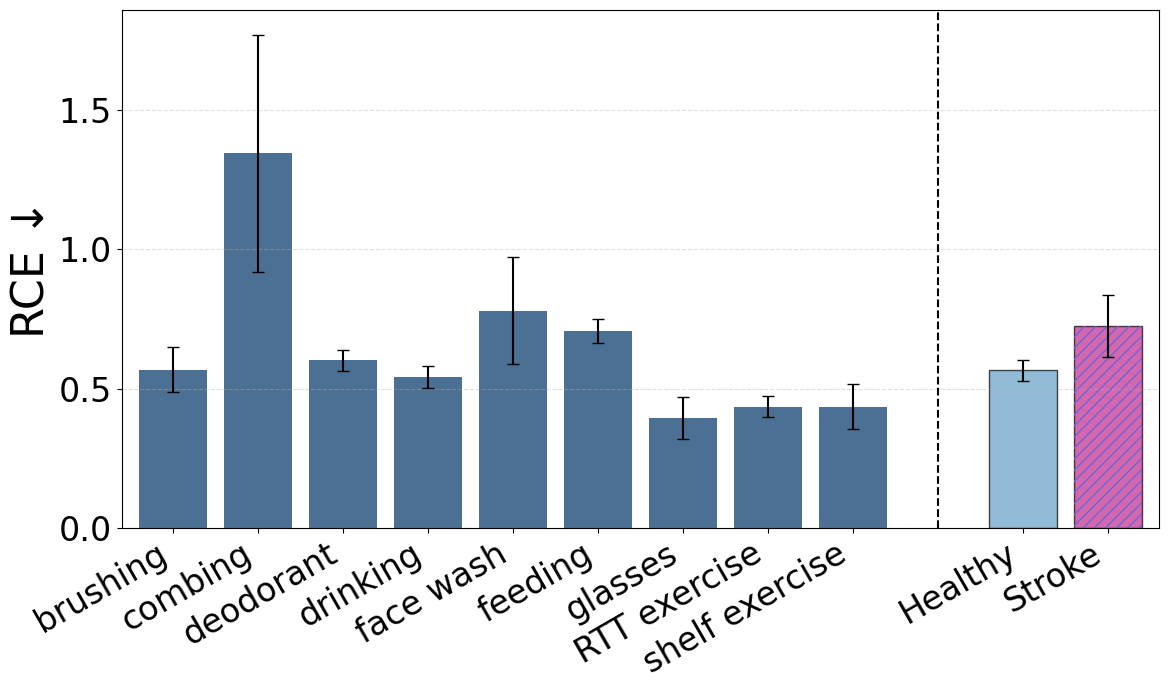

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_scores_by_activity_and_cohort(df_samples: pd.DataFrame):
    """
    Combined plot of mean ± SEM for Edit Score and Action Error Rate (AER),
    showing activities (alphabetically sorted) and stroke cohorts.

    Expects columns:
      - 'activity_cleaned'
      - 'edit_score'
      - 'action_error_rate'
      - 'stroke' (bool)

    Stroke == True  → "Mild/Moderate"
    Stroke == False → "Control"
    """
    df = df_samples.copy()
    df["cohort"] = df["stroke"].map({True: "Stroke", False: "Healthy"})

    # --- Group 1: by activity ---
    act_grouped = df.groupby("activity_cleaned")[["edit_score", "action_error_rate", "relative_counting_error"]]
    act_stats = act_grouped.agg(["mean", "std", "count"])
    act_stats.columns = ["_".join(c) for c in act_stats.columns]
    # act_stats = act_stats.sort_index()  # alphabetical
    act_stats = act_stats.sort_index(key=lambda s: s.str.lower().str.strip())


    # --- Group 2: by cohort ---
    coh_grouped = df.groupby("cohort")[["edit_score", "action_error_rate", "relative_counting_error"]]
    coh_stats = coh_grouped.agg(["mean", "std", "count"])
    coh_stats.columns = ["_".join(c) for c in coh_stats.columns]

    # --- SEM ---
    def sem(std, n):
        return std / np.sqrt(np.maximum(n, 1))

    for metric, ylabel in [
        # ("edit_score", "Edit Score"),
        # ("action_error_rate", "Action Error Rate"),
        ("relative_counting_error", "RCE ↓"),
    ]:
        fig, ax = plt.subplots(figsize=(12, 7))

        # Activities (left)
        means_act = act_stats[f"{metric}_mean"]
        errs_act = sem(act_stats[f"{metric}_std"], act_stats[f"{metric}_count"])
        x_acts = np.arange(len(means_act))
        ax.bar(x_acts, means_act, yerr=errs_act, capsize=4, alpha=0.7, color="#003366", label="Activity")

        # Add dashed separator
        sep = len(x_acts) - 0.5
        ax.axvline(sep + 0.5, color="black", linestyle="--", linewidth=1.5)

        # Cohorts (right)
        means_coh = coh_stats[f"{metric}_mean"]
        errs_coh = sem(coh_stats[f"{metric}_std"], coh_stats[f"{metric}_count"])
        x_coh = np.arange(len(means_coh)) + len(x_acts) + 1
        
        first_bar_color = "#649FC7"  # Healthy
        second_bar_colors = ["#6F64D4", "#C2288C"]  # Mild/Moderate with different styles

        ax.bar(
            x_coh[0], means_coh[0], yerr=errs_coh[0],
            capsize=4, alpha=0.7,
            color=first_bar_color, edgecolor="black", linewidth=1.0
        )

        # --- Second bar (Mild/Moderate, overlay mix) ---
        # Base violet layer
        ax.bar(
            x_coh[1], means_coh[1], yerr=errs_coh[1],
            capsize=4, alpha=0.7,
            color=second_bar_colors[1], edgecolor="black", linewidth=1.0
        )
        # Pink hatched overlay
        ax.bar(
            x_coh[1], means_coh[1],
            color="none", edgecolor=second_bar_colors[0],
            hatch="///", linewidth=0.0
        )

        # --- X-axis labels ---
        xticks = list(x_acts) + list(x_coh)
        xticklabels = list(means_act.index) + list(means_coh.index)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, rotation=30, ha="right")

        # --- Styling ---
        ax.set_ylabel(ylabel, fontsize=32)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.tick_params(axis="x", labelsize=24)
        ax.tick_params(axis="y", labelsize=24)
        ax.set_xlim(-0.6, x_coh[-1] + 0.6)
        plt.tight_layout()


plot_scores_by_activity_and_cohort(df_samples)
plt.savefig("./rce_breakdown.pdf", bbox_inches='tight', dpi=300)
plt.show()

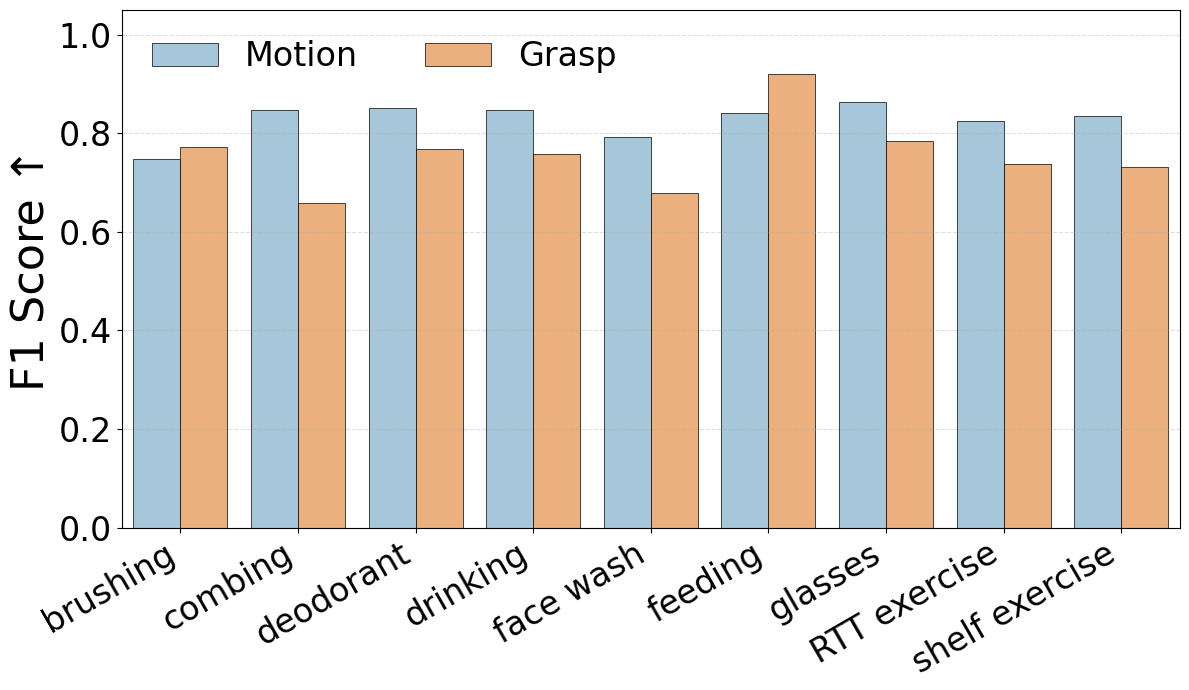

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_f1_by_activity(df_samples: pd.DataFrame,
                        df_resps: pd.DataFrame,
                        which: str = "both"):
    """
    Plot F1 breakdown by activity for motion/grasp (middle & window GTs).

    Args
    ----
    df_samples : pd.DataFrame
    df_resps   : pd.DataFrame
    which      : {"middle","window","both"}  -> which GT granularity to plot

    Color families:
      - Motion: blue (light = middle, dark = window)
      - Grasp:  orange (light = middle, dark = window)
    """
    which = which.lower()
    if which not in {"middle", "window", "both"}:
        raise ValueError("`which` must be one of {'middle','window','both'}")

    df = df_resps.merge(df_samples[["id", "activity_cleaned"]], on="id", how="left")

    def masked_f1(gt, pred):
        mask = (~pd.isna(gt)) & (~pd.isna(pred))
        if mask.sum() == 0:
            return 0.0
        y_true, y_pred = gt[mask].astype(bool), pred[mask].astype(bool)
        tp = ((y_true) & (y_pred)).sum()
        fp = ((~y_true) & (y_pred)).sum()
        fn = ((y_true) & (~y_pred)).sum()
        return (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

    # Full mapping, then restrict based on `which`
    mapping_all = {
        "motion_middle": ("motion_gt_middle", "motion_pred"),
        "motion_window": ("motion_gt_window", "motion_pred"),
        "grasp_middle":  ("grasp_gt_middle",  "grasp_pred"),
        "grasp_window":  ("grasp_gt_window",  "grasp_pred"),
    }
    subset_by_which = {
        "both":   ["motion_middle", "motion_window", "grasp_middle", "grasp_window"],
        "middle": ["motion_middle", "grasp_middle"],
        "window": ["motion_window", "grasp_window"],
    }
    types_to_use = subset_by_which[which]
    mapping = {k: v for k, v in mapping_all.items() if k in types_to_use}

    rows = []
    for act, g in df.groupby("activity_cleaned"):
        for typ, (gt_col, pred_col) in mapping.items():
            if gt_col not in g.columns or pred_col not in g.columns:
                continue
            f1 = masked_f1(g[gt_col], g[pred_col])
            rows.append({"activity": act, "type": typ, "f1": f1})
    df_f1 = pd.DataFrame(rows)
    df_f1 = df_f1.sort_values(
        "activity",
        key=lambda s: s.str.lower().str.strip(),
        ascending=True
    )


    if df_f1.empty:
        print("No data to plot for the selected setting.")
        return

    # Colors: consistent hue per signal, lighter for middle
    colors_all = {
        "motion_middle": "#9ecae1",  # light blue
        "motion_window": "#08519c",  # dark blue
        "grasp_middle":  "#fdae6b",  # light orange
        "grasp_window":  "#d94801",  # dark orange
    }
    labels_all = {
        "motion_middle": "Motion (middle)",
        "motion_window": "Motion (window)",
        "grasp_middle":  "Grasp (middle)",
        "grasp_window":  "Grasp (window)",
    }

    order = types_to_use  # preserve the intended order per selection
    df_f1["type"] = pd.Categorical(df_f1["type"], categories=order, ordered=True)

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=df_f1, x="activity", y="f1",
        hue="type", hue_order=order,
        palette=[colors_all[t] for t in order],
        edgecolor="black", linewidth=0.5,
    )

    plt.ylabel("F1 Score ↑", fontsize=32)
    plt.xlabel("")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right", fontsize=24)
    plt.yticks(fontsize=24)

    # Legend reflecting only what's plotted
    handles, _ = ax.get_legend_handles_labels()
    new_labels = [labels_all[t] for t in order]
    if which != "both":
        # No parentheses needed
        new_labels = [lbl.replace(" (middle)", "").replace(" (window)", "") for lbl in new_labels]
    ax.legend(handles, new_labels, fontsize=24, loc="upper left", frameon=False, ncol=len(new_labels))

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()



plot_f1_by_activity(df_samples, df_resps, which="middle")
plt.savefig("./motion_grasp_f1_by_activity.pdf", bbox_inches='tight', dpi=300)
plt.show()

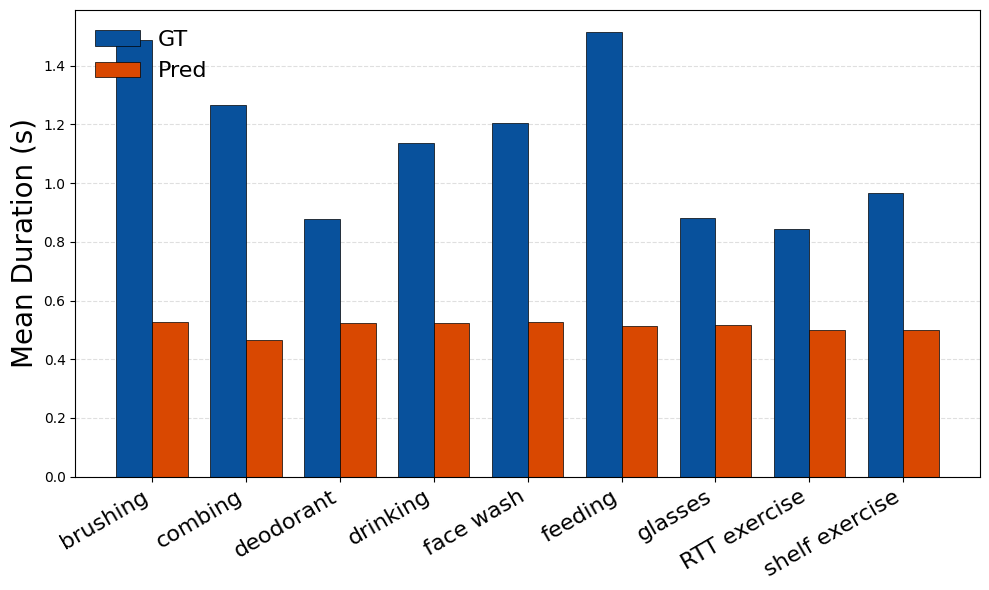

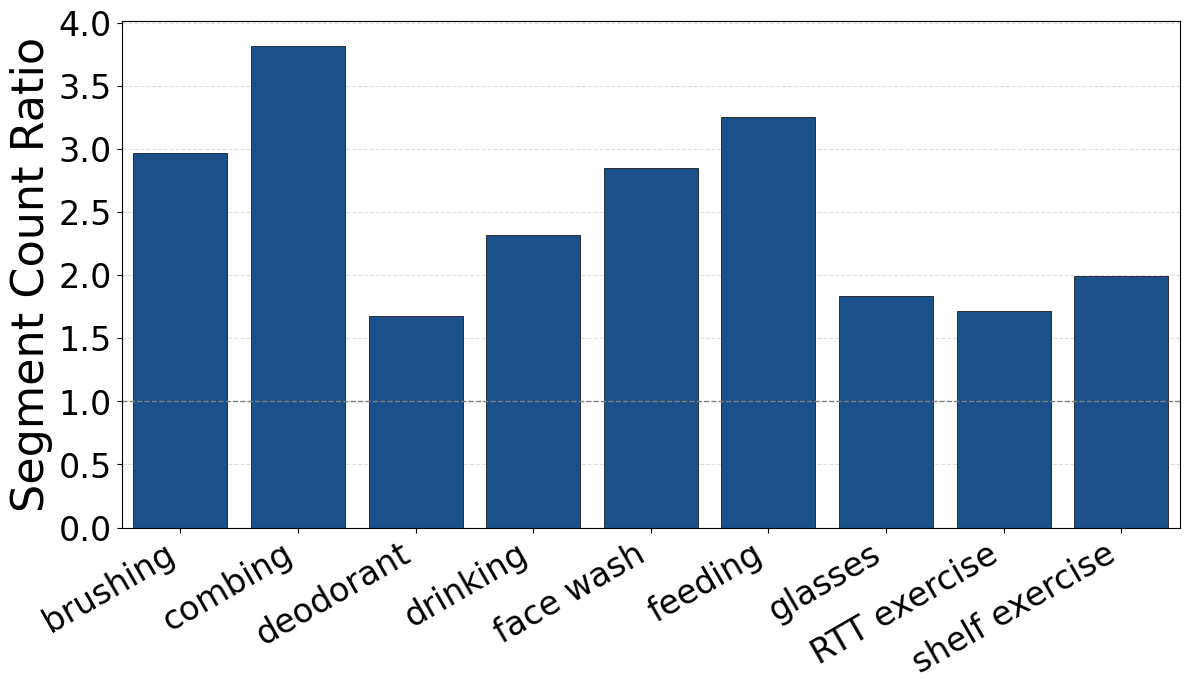

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_avg_primitive_duration(
    df_samples: pd.DataFrame,
    get_gt_prims,
    primitive: str | None = None,
    agg: str = "mean",   # {"mean","sum"}
):
    """
    Compare duration of a primitive between GT and Pred by activity_cleaned.
    If `primitive` is None/"" -> aggregate across ALL primitives using `agg`.

    df_samples must have: ['id','activity_cleaned','path_l','filtered_resps','duration_s']
    get_gt_prims(path_l) -> (prims, times) with sorted `times`.
    """

    def durations_from_prims(prims, times, dur_end):
        """Return dict {primitive: [durations...]} for an entire video."""
        ends = list(times[1:]) + [dur_end]
        durs = {}
        for p, t0, t1 in zip(prims, times, ends):
            durs.setdefault(p, []).append(max(0.0, t1 - t0))
        return durs

    rows = []  # (activity_cleaned, source, duration)

    for _, r in df_samples.iterrows():
        act   = r.get("activity_cleaned", r.get("activity"))
        if act is None:
            continue
        T_end = float(r["duration_s"])

        # --- GT ---
        try:
            gt_prims, gt_times = get_gt_prims(r["path_l"])
            gt_durs = durations_from_prims(gt_prims, gt_times, T_end)
            if primitive:  # specific primitive
                for d in gt_durs.get(primitive, []):
                    rows.append((act, "GT", d))
            else:  # aggregate over all primitives
                for d in (d for L in gt_durs.values() for d in L):
                    rows.append((act, "GT", d))
        except Exception:
            pass

        # --- Pred (from filtered_resps "prim@time;prim@time;...") ---
        try:
            parts = [p.split("@") for p in str(r["filtered_resps"]).split(";") if "@" in p]
            if not parts:
                continue
            pred_prims = [p[0] for p in parts]
            pred_times = [float(p[1]) for p in parts]
            pred_durs  = durations_from_prims(pred_prims, pred_times, T_end)
            if primitive:
                for d in pred_durs.get(primitive, []):
                    rows.append((act, "Pred", d))
            else:
                for d in (d for L in pred_durs.values() for d in L):
                    rows.append((act, "Pred", d))
        except Exception:
            pass

    df_all = pd.DataFrame(rows, columns=["activity_cleaned","source","duration"])
    if df_all.empty:
        print(f"No data found for primitive '{primitive}' (agg='{agg}').")
        return None

    if agg not in {"mean","sum"}:
        raise ValueError("agg must be 'mean' or 'sum'")

    agg_fn = {"mean":"mean","sum":"sum"}[agg]
    df_summary = (
        df_all.groupby(["activity_cleaned","source"], as_index=False)["duration"]
        .agg(agg_fn)
        .rename(columns={"duration": f"{agg}_duration"})
    )

    # ---- STYLE MATCH: alphabetical activities (case/space-insensitive), figure, grid, labels ----
    df_summary["activity_cleaned"] = pd.Categorical(
        df_summary["activity_cleaned"],
        categories=sorted(df_summary["activity_cleaned"].unique(), key=lambda s: s.lower().strip()),
        ordered=True
    )
    df_summary = df_summary.sort_values("activity_cleaned")

    acts = df_summary["activity_cleaned"].cat.categories.tolist()
    width = 0.38
    x = np.arange(len(acts))

    # Align GT/Pred per activity
    colname = f"{agg}_duration"
    y_gt = []
    y_pr = []
    for a in acts:
        sub = df_summary[df_summary["activity_cleaned"] == a]
        y_gt.append(float(sub.loc[sub["source"] == "GT", colname].sum()))
        y_pr.append(float(sub.loc[sub["source"] == "Pred", colname].sum()))

    # Colors to match the bold tones used in your F1 plot
    color_gt   = "#08519c"  # dark blue
    color_pred = "#d94801"  # dark orange

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, y_gt,  width=width, label="GT",
            color=color_gt, edgecolor="black", linewidth=0.5)
    plt.bar(x + width/2, y_pr,  width=width, label="Pred",
            color=color_pred, edgecolor="black", linewidth=0.5)

    title_prim = primitive if primitive else "ALL primitives"
    # no x-label (match style), keep strong y-label
    plt.ylabel(f"{agg.capitalize()} Duration (s)", fontsize=20)
    plt.xlabel("")
    plt.xticks(x, acts, rotation=30, ha="right", fontsize=16)
    plt.ylim(bottom=0)
    plt.legend(frameon=False, fontsize=16, loc="upper left")

    # grid like F1
    ax = plt.gca()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()

    return df_summary


def plot_segment_count_ratio(df_samples: pd.DataFrame):
    """
    Plot average ratio (#predicted segments / #GT segments) per activity_cleaned.

    Requires columns: ['activity_cleaned', 'target', 'filtered_resps']
    """
    ratios = []
    for _, row in df_samples.iterrows():
        act = row.get("activity_cleaned", row.get("activity"))
        if act is None:
            continue
        try:
            n_gt   = sum("@" in p for p in str(row["target"]).split(";"))
            n_pred = sum("@" in p for p in str(row["filtered_resps"]).split(";"))
            if n_gt > 0:
                ratios.append({"activity_cleaned": act, "ratio": n_pred / n_gt})
        except Exception:
            continue

    df_ratio = pd.DataFrame(ratios)
    if df_ratio.empty:
        print("No valid data to compute segment count ratios.")
        return

    df_summary = (
        df_ratio.groupby("activity_cleaned", as_index=False)["ratio"]
        .mean()
    )

    # ---- STYLE MATCH: alphabetical activities (case/space-insensitive), figure, grid, labels ----
    df_summary["activity_cleaned"] = pd.Categorical(
        df_summary["activity_cleaned"],
        categories=sorted(df_summary["activity_cleaned"].unique(), key=lambda s: s.lower().strip()),
        ordered=True
    )
    df_summary = df_summary.sort_values("activity_cleaned")

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=df_summary, x="activity_cleaned", y="ratio",
        color="#08519c",  # match F1's dark blue family
        edgecolor="black", linewidth=0.5
    )

    # style & annotations (match F1)
    plt.axhline(1.0, color="gray", linestyle="--", lw=1)
    plt.ylabel("Segment Count Ratio", fontsize=32)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right", fontsize=24)
    plt.yticks(fontsize=24)

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()

    return df_summary


# Example:
# for primitive in ['idle', 'reach', 'transport', 'reposition', 'stabilize']:
_ = plot_avg_primitive_duration(df_samples, get_gt_prims)
# plt.show()
_ = plot_segment_count_ratio(df_samples)
plt.savefig("./segment_count_ratio.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [78]:
df_samples['activity_cleaned']

0       RTT exercise
1           brushing
2            combing
3          deodorant
4           drinking
           ...      
85          drinking
86         face wash
87           feeding
88           glasses
89    shelf exercise
Name: activity_cleaned, Length: 90, dtype: object

In [80]:
df_resps.head()

,id,segment_idx,t0,t1,dt,answer_raw,motion_pred,grasp_pred,prims_window,motion_gt_middle,grasp_gt_middle,motion_gt_window,grasp_gt_window
0,S00011_RTT right side1_1,0,0.000,0.533,0.533,idle,None,None,[idle],False,False,False,False
1,S00011_RTT right side1_1,1,0.533,1.067,0.534,idle,None,None,[idle],False,False,False,False
2,S00011_RTT right side1_1,2,1.067,1.600,0.533,transport,None,None,"[idle, reach]",True,False,<NA>,False
3,S00011_RTT right side1_1,3,1.600,2.133,0.533,transport,None,None,"[reach, transport]",True,False,True,<NA>
4,S00011_RTT right side1_1,4,2.133,2.667,0.534,transport,None,None,[transport],True,True,True,True


In [79]:
analyze_df_resps(df_resps)

=== F1 EVALUATION (Masked + Bounds for window) ===

[Motion (middle)]
  Masked F1: 0.0000  | TP=0 FP=0 FN=0
  Coverage: 0/9064 (0.0%) rows with non-NA GT & prediction

[Grasp  (middle)]
  Masked F1: 0.0000  | TP=0 FP=0 FN=0
  Coverage: 0/9064 (0.0%) rows with non-NA GT & prediction

[Motion (window)]
  Masked F1: 0.0000  | TP=0 FP=0 FN=0
  Coverage: 0/9064 (0.0%) rows with non-NA GT & prediction
  Optimistic bound F1:  0.0000  | TP=0 FP=0 FN=0  (coverage 0.0%)
  Pessimistic bound F1: 0.0000  | TP=0 FP=0 FN=0  (coverage 0.0%)
  Mixed GT rows used in bounds (GT=NA, pred valid): 0
  Rows with pred NA (excluded from all): 9064

[Grasp  (window)]
  Masked F1: 0.0000  | TP=0 FP=0 FN=0
  Coverage: 0/9064 (0.0%) rows with non-NA GT & prediction
  Optimistic bound F1:  0.0000  | TP=0 FP=0 FN=0  (coverage 0.0%)
  Pessimistic bound F1: 0.0000  | TP=0 FP=0 FN=0  (coverage 0.0%)
  Mixed GT rows used in bounds (GT=NA, pred valid): 0
  Rows with pred NA (excluded from all): 9064



{'Motion (middle)': {'masked': {'f1': 0.0,
   'tp': 0,
   'fp': 0,
   'fn': 0,
   'n_eval': 0,
   'n_total': 9064,
   'coverage': 0.0},
  'bounds': None},
 'Grasp  (middle)': {'masked': {'f1': 0.0,
   'tp': 0,
   'fp': 0,
   'fn': 0,
   'n_eval': 0,
   'n_total': 9064,
   'coverage': 0.0},
  'bounds': None},
 'Motion (window)': {'masked': {'f1': 0.0,
   'tp': 0,
   'fp': 0,
   'fn': 0,
   'n_eval': 0,
   'n_total': 9064,
   'coverage': 0.0},
  'bounds': {'optimistic': {'tp': 0,
    'fp': 0,
    'fn': 0,
    'f1': 0.0,
    'n_eval': 0,
    'coverage': 0.0},
   'pessimistic': {'tp': 0,
    'fp': 0,
    'fn': 0,
    'f1': 0.0,
    'n_eval': 0,
    'coverage': 0.0},
   'n_gt_mixed_used': 0,
   'n_pred_na': 9064,
   'n_total': 9064}},
 'Grasp  (window)': {'masked': {'f1': 0.0,
   'tp': 0,
   'fp': 0,
   'fn': 0,
   'n_eval': 0,
   'n_total': 9064,
   'coverage': 0.0},
  'bounds': {'optimistic': {'tp': 0,
    'fp': 0,
    'fn': 0,
    'f1': 0.0,
    'n_eval': 0,
    'coverage': 0.0},
   'pes

### Intervention

In [134]:
# First, let's make sure we can calculate stuff stuff correctly
print(f"Target AER and edit score: {df_samples['action_error_rate'].iloc[0]:.4f}, {df_samples['edit_score'].iloc[0]:.2f}")

from lmms_eval.tasks.strokerehab.utils_primitives import _get_primitives_score
target_list = [x['action'] for x in _parse_segments(df_samples['target'].iloc[0])]
pred_list   = [x['action'] for x in _parse_segments(df_samples['filtered_resps'].iloc[0])]
scores = _get_primitives_score(pred_list, target_list)
print(f"Calculated AER and edit score: {scores['action_error_rate']:.4f}, {scores['edit_score']:.2f}")

Target AER and edit score: 0.2424, 75.76
Calculated AER and edit score: 0.2424, 75.76


In [137]:
def smooth_filtered_resps(resp_str: str) -> str:
    """
    Smooth a semicolon-delimited primitive string:
      If primitive[i-1] == primitive[i+1] != primitive[i],
      switch primitive[i] to its neighbors' primitive.

    Example:
      'idle@0;reach@1;idle@2' -> 'idle@0;idle@1;idle@2'
    """
    if not isinstance(resp_str, str) or "@" not in resp_str:
        return resp_str

    # Parse "prim@time" segments
    parts = [p.split("@") for p in resp_str.split(";") if "@" in p]
    prims = [p[0] for p in parts]
    times = [p[1] for p in parts]

    # Apply smoothing rule
    smoothed = prims.copy()
    for i in range(1, len(prims) - 1):
        prev_p, cur_p, next_p = prims[i - 1], prims[i], prims[i + 1]
        if prev_p == next_p and cur_p != prev_p:
            smoothed[i] = prev_p

    # Reconstruct string
    smoothed_str = ";".join(f"{p}@{t}" for p, t in zip(smoothed, times))
    return smoothed_str

In [140]:
df_samples['smoothed_filtered_resps'] = df_samples['filtered_resps'].apply(smooth_filtered_resps)

In [ ]:
df_samples

In [142]:
# Calculate new scores after smoothing
def calculate_scores(row):
    target_list = [x['action'] for x in _parse_segments(row['target'])]
    pred_list   = [x['action'] for x in _parse_segments(row['smoothed_filtered_resps'])]
    scores = _get_primitives_score(pred_list, target_list)
    return pd.Series({'smoothed_action_error_rate': scores['action_error_rate'],
                      'smoothed_edit_score': scores['edit_score']})

In [143]:
df_samples[['smoothed_action_error_rate', 'smoothed_edit_score']] = df_samples.apply(calculate_scores, axis=1)

In [147]:
df_samples['smoothed_action_error_rate'].mean(), df_samples['smoothed_edit_score'].mean()

(0.6643714803975912, 39.17419276528012)

In [145]:
df_samples.columns

Index(['id', 'patient', 'activity', 'duration_s', 'target', 'path_l', 'path_v',
       'filtered_resps', 'stroke', 'edit_score', 'action_error_rate',
       'resps_json', 'prompt_input', 'activity_cleaned', 'target_lengths',
       'smoothed_filtered_resps', 'smoothed_action_error_rate',
       'smoothed_edit_score'],
      dtype='object')

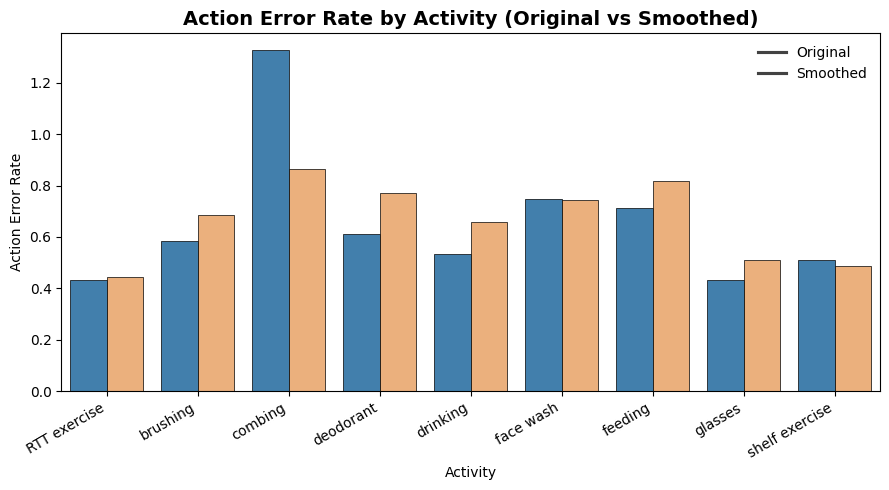

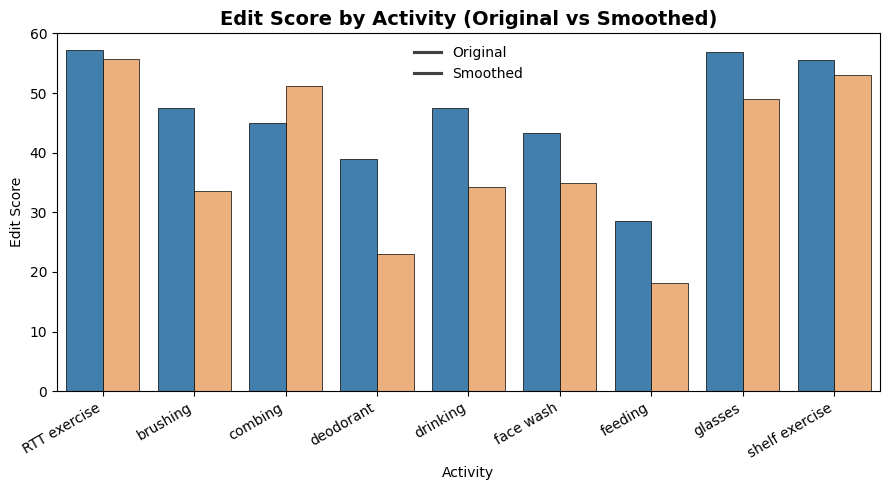

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_metric_comparison(df_samples: pd.DataFrame, metric: str, smooth_metric: str, ylabel: str | None = None):
    """
    Compare original vs smoothed metric by activity_cleaned.

    Parameters
    ----------
    df_samples : DataFrame
        Must contain columns ['activity_cleaned', metric, smooth_metric]
    metric : str
        Column name of original metric (e.g., 'action_error_rate')
    smooth_metric : str
        Column name of smoothed metric (e.g., 'smoothed_action_error_rate')
    ylabel : str
        Optional custom y-axis label
    """
    df = df_samples.copy()
    if "activity_cleaned" not in df.columns:
        print("Missing column: activity_cleaned")
        return

    df_long = (
        df.melt(
            id_vars=["activity_cleaned"],
            value_vars=[metric, smooth_metric],
            var_name="type", value_name="value"
        )
        .groupby(["activity_cleaned", "type"], as_index=False)["value"].mean()
    )

    palette = {metric: "#3182bd", smooth_metric: "#fdae6b"}

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=df_long,
        x="activity_cleaned", y="value", hue="type",
        palette=palette, edgecolor="black", linewidth=0.5
    )

    title_label = ylabel or metric.replace("_", " ").title()
    plt.title(f"{title_label} by Activity (Original vs Smoothed)", fontsize=14, weight="semibold")
    plt.ylabel(title_label)
    plt.xlabel("Activity")
    plt.xticks(rotation=30, ha="right")
    plt.legend(
        labels=["Original", "Smoothed"],
        title="", loc="best", frameon=False
    )
    plt.tight_layout()
    plt.show()


plot_metric_comparison(df_samples, "action_error_rate", "smoothed_action_error_rate", ylabel="Action Error Rate")
plot_metric_comparison(df_samples, "edit_score", "smoothed_edit_score", ylabel="Edit Score")

In [156]:
df_samples

,id,patient,activity,duration_s,target,path_l,path_v,filtered_resps,stroke,edit_score,action_error_rate,resps_json,prompt_input,activity_cleaned,target_lengths,smoothed_filtered_resps,smoothed_action_error_rate,smoothed_edit_score
0,S00011_RTT right side1_1,S00011,RTT right side,60.817,idle@0.000;reach@1.267;transport@2.017;reposit...,S00011/S00011_RTT right side1_1.csv,S00011/S00011_RTT right side1_1.avi,idle@0.000;idle@0.533;reach@1.067;transport@1....,True,75.757576,0.242424,"[[[[""NO <SEP> NO"", ""0.0"", ""0.533""], [""NO <SEP>...",Focus on the patient's RIGHT hand. Is it activ...,RTT exercise,67,idle@0.000;idle@0.533;reach@1.067;transport@1....,0.303030,69.696970
1,S00011_brushing1_1,S00011,brushing,100.150,idle@0.000;reach@5.467;stabilize@5.933;transpo...,S00011/S00011_brushing1_1.csv,S00011/S00011_brushing1_1.avi,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,True,63.013699,0.369863,"[[[[""NO <SEP> NO"", ""0.0"", ""0.533""], [""NO <SEP>...",Focus on the patient's RIGHT hand. Is it activ...,brushing,74,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,0.561644,43.835616
2,S00011_combing1_1,S00011,combing,12.383,idle@0.000;reach@1.067;stabilize@2.117;transpo...,S00011/S00011_combing1_1.csv,S00011/S00011_combing1_1.avi,idle@0.000;idle@0.533;reposition@1.067;idle@1....,True,50.000000,0.833333,"[[[[""NO <SEP> NO"", ""0.0"", ""0.533""], [""NO <SEP>...",Focus on the patient's RIGHT hand. Is it activ...,combing,7,idle@0.000;idle@0.533;idle@1.067;reposition@1....,0.333333,66.666667
3,S00011_deodrant1_1,S00011,deodrant,19.650,idle@0.000;reach@0.867;stabilize@1.917;transpo...,S00011/S00011_deodrant1_1.csv,S00011/S00011_deodrant1_1.avi,idle@0.000;idle@0.533;idle@1.067;transport@1.6...,True,40.000000,0.600000,"[[[[""NO <SEP> NO"", ""0.0"", ""0.533""], [""NO <SEP>...",Focus on the patient's RIGHT hand. Is it activ...,deodorant,31,idle@0.000;idle@0.533;idle@1.067;transport@1.6...,0.733333,26.666667
4,S00011_drinking1_1,S00011,drinking,25.350,idle@0.000;reach@1.117;stabilize@2.167;transpo...,S00011/S00011_drinking1_1.csv,S00011/S00011_drinking1_1.avi,idle@0.000;idle@0.533;reach@1.067;transport@1....,True,40.000000,0.600000,"[[[[""NO <SEP> NO"", ""0.0"", ""0.533""], [""NO <SEP>...",Focus on the patient's RIGHT hand. Is it activ...,drinking,36,idle@0.000;idle@0.533;reach@1.067;transport@1....,0.771429,22.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,C00029_drinking1_1,C00029,drinking,91.146,idle@0.000;reach@1.650;transport@2.700;reach@3...,C00029/C00029_drinking1_1.csv,C00029/C00029_drinking1_1.mkv,idle@0.000;idle@0.533;idle@1.067;transport@1.6...,False,52.112676,0.478873,"[[[[""NO <SEP> NO"", ""0.0"", ""0.533""], [""NO <SEP>...",Focus on the patient's RIGHT hand. Is it activ...,drinking,72,idle@0.000;idle@0.533;idle@1.067;transport@1.6...,0.591549,40.845070
86,C00029_face wash1_1,C00029,face wash,182.425,idle@4.001;reach@6.568;stabilize@7.168;transpo...,C00029/C00029_face wash1_1.csv,C00029/C00029_face wash1_1.mkv,transport@0.000;idle@0.533;reach@1.067;reach@1...,False,52.898551,0.471014,"[[[[""YES <SEP> YES"", ""0.0"", ""0.533""], [""NO <SE...",Focus on the patient's RIGHT hand. Is it activ...,face wash,139,transport@0.000;idle@0.533;reach@1.067;reach@1...,0.688406,31.159420
87,C00029_feeding1_1,C00029,feeding,134.152,idle@0.000;reach@3.417;transport@5.201;reach@5...,C00029/C00029_feeding1_1.csv,C00029/C00029_feeding1_1.mkv,idle@0.000;idle@0.533;idle@1.067;idle@1.600;re...,False,30.000000,0.700000,"[[[[""NO <SEP> NO"", ""0.0"", ""0.533""], [""NO <SEP>...",Focus on the patient's RIGHT hand. Is it activ...,feeding,61,idle@0.000;idle@0.533;idle@1.067;idle@1.600;re...,0.816667,18.333333
88,C00029_glasses1_1,C00029,glasses,58.541,idle@0.000;reach@0.900;transport@1.900;reach@3...,C00029/C00029_glasses1_1.csv,C00029/C00029_glasses1_1.mkv,idle@0.000;idle@0.533;reach@1.067;transport@1....,False,65.573770,0.344262,"[[[[""NO <SEP> NO"", ""0.0"", ""0.533""], [""NO <SEP>...",Focus on the patient's RIGHT ha

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PRIMITIVE_COLORS = {
    "reach": (255, 165, 0),      # Orange
    "reposition": (0, 191, 255), # Deep Sky Blue
    "transport": (34, 139, 34),  # Forest Green
    "stabilize": (75, 0, 130),   # Indigo
    "idle": (169, 169, 169),     # Dark Gray
}

def plot_motion_grasp_timeline(df_samples: pd.DataFrame, activity_cleaned: str):
    """
    Pick a random id for a given activity_cleaned and plot ground-truth vs predicted
    motion/grasp primitives (from `target` and `filtered_resps`) as horizontal bars.

    Parameters
    ----------
    df_samples : pd.DataFrame
        Must contain ['activity_cleaned', 'id', 'target', 'filtered_resps', 'duration_s']
    activity_cleaned : str
        The activity group to visualize
    """
    # --- Select a random ID uniformly ---
    sub = df_samples[df_samples["activity_cleaned"] == activity_cleaned]
    if sub.empty:
        print(f"No samples found for activity '{activity_cleaned}'.")
        return
    row = sub.sample(1, random_state=None).iloc[0]
    vid_id = row["id"]
    vid_dur = float(row["duration_s"])
    print(f"Showing timeline for activity '{activity_cleaned}'  (id={vid_id})")

    # --- Helper: parse "prim@time" strings ---
    def parse_segments(s: str, dur_end: float):
        parts = [p.split("@") for p in str(s).split(";") if "@" in p]
        prims = [p[0] for p in parts]
        times = [float(p[1]) for p in parts]
        if not times:
            return [], []
        ends = times[1:] + [dur_end]
        return list(zip(prims, times, ends))

    gt_segments = parse_segments(row["target"], vid_dur)
    pr_segments = parse_segments(row["filtered_resps"], vid_dur)

    if not gt_segments or not pr_segments:
        print("Missing or malformed target/predicted segments.")
        return

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.set_xlim(0, vid_dur)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("Time (s)")
    ax.set_title(f"GT vs Pred Motion/Grasp — {activity_cleaned} (id={vid_id})", fontsize=13, weight="semibold")

    # --- Draw GT (top) and Pred (bottom) bars ---
    bar_height = 0.35

    for prim, t0, t1 in gt_segments:
        color = tuple(c/255 for c in PRIMITIVE_COLORS.get(prim, (0,0,0)))
        ax.barh(1, width=t1-t0, left=t0, height=bar_height, color=color, edgecolor="none")

    for prim, t0, t1 in pr_segments:
        color = tuple(c/255 for c in PRIMITIVE_COLORS.get(prim, (0,0,0)))
        ax.barh(0, width=t1-t0, left=t0, height=bar_height, color=color, edgecolor="none")

    # --- Y labels ---
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Predicted", "Ground Truth"], fontsize=10)

    # --- Legend ---
    patches = [
        mpatches.Patch(color=tuple(c/255 for c in col), label=prim)
        for prim, col in PRIMITIVE_COLORS.items()
    ]
    ax.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="Primitive")

    plt.tight_layout()
    plt.show()


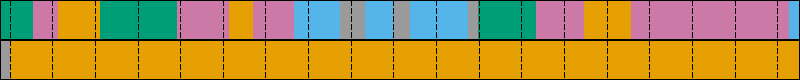

In [69]:
def parse_timeline_string(timeline_str):
    """Parses a timeline string like 'IDLE@0.000;REACH@0.533;...'
    into a list of (primitive, start_time, end_time) tuples."""
    parsed_events = []
    events = timeline_str.strip().split(';')
    
    current_time = 0.0
    for i, event_str in enumerate(events):
        if not event_str:
            continue
        parts = event_str.split('@')
        if len(parts) != 2:
            print(f"Warning: Malformed event string: {event_str}")
            continue
        
        primitive = parts[0].lower() # Convert to lowercase to match dict keys
        start_time = float(parts[1])

        # Determine end time for the current event
        if i + 1 < len(events):
            next_event_str = events[i+1]
            if not next_event_str: # Handle case where last element is empty after split
                end_time = float('inf') 
            else:
                next_start_time = float(next_event_str.split('@')[1])
                end_time = next_start_time
        else:
            # For the last event, assume it continues indefinitely or until the video end.
            # We'll clip it later based on the requested end_time for the drawing.
            end_time = float('inf') 
        
        parsed_events.append((primitive, start_time, end_time))
    return parsed_events


def draw_primitive_timeline(df_row, video_start_time, video_end_time,
                            chunk_time=0.533, bar_height=40, bar_spacing=0,
                            img_width=800):
    """
    Draws two horizontal bars representing 'target' and 'filtered_resps' timelines
    for a given video segment, including vertical dashed lines at chunk_time intervals,
    with centered, white labels.

    :param df_row: A pandas Series or DataFrame row containing 'target' and 'filtered_resps'.
    :param video_start_time: The start time (in seconds) of the video segment to draw.
    :param video_end_time: The end time (in seconds) of the video segment to draw.
    :param chunk_time: The interval (in seconds) for drawing vertical dashed lines.
                       If None or 0, no chunk lines are drawn. (Default: 0.533)
    :param bar_height: Height of each timeline bar in pixels.
    :param bar_spacing: Vertical space between the two bars in pixels.
    :param img_width: Total width of the output image in pixels.
    :return: A PIL Image object.
    """
    
    # Extract the single row of data (robust extraction logic)
    if hasattr(df_row, 'iloc') and len(df_row) > 0:
        df_row = df_row.iloc[0]
    elif isinstance(df_row, pd.DataFrame) and not df_row.empty:
        df_row = df_row.iloc[0]
    elif isinstance(df_row, np.ndarray) and df_row.ndim > 0:
        df_row = df_row[0]
    
    target_timeline_str = df_row['target']
    filtered_resps_timeline_str = df_row['filtered_resps']

    # Parse the timeline strings
    target_events = parse_timeline_string(target_timeline_str)
    filtered_resps_events = parse_timeline_string(filtered_resps_timeline_str)

    # Calculate image dimensions (2 bars + 1 spacing between + 2 border spacing)
    # The extra bar_spacing accounts for padding at the top and bottom
    img_height = (bar_height * 2) + bar_spacing + (2 * bar_spacing)
    
    # Create a blank white image
    img = Image.new('RGB', (img_width, img_height), 'white')
    draw = ImageDraw.Draw(img)

    # Calculate horizontal scale (pixels per second)
    duration_to_draw = video_end_time - video_start_time
    if duration_to_draw <= 0:
        print("Error: video_end_time must be greater than video_start_time.")
        return img
        
    px_per_sec = img_width / duration_to_draw

    # Y-coordinates for the bars
    target_y_start = bar_spacing
    filtered_resps_y_start = target_y_start + bar_height + bar_spacing

    # --- Helper function to draw events on a bar ---
    def draw_bar(events, y_start, label):
        # 1. Draw the colored segments
        for primitive, start_t, end_t in events:
            # Clip event times to the requested video segment
            segment_start_t = max(start_t, video_start_time)
            segment_end_t = min(end_t, video_end_time)

            if segment_end_t <= segment_start_t:
                continue

            # Convert times to pixel coordinates relative to the image width
            x1 = int((segment_start_t - video_start_time) * px_per_sec)
            x2 = int((segment_end_t - video_start_time) * px_per_sec)

            # Ensure x1 and x2 are within image bounds
            x1 = max(0, x1)
            x2 = min(img_width, x2)
            
            if x2 <= x1:
                continue

            color = PRIMITIVE_COLORS.get(primitive, (128, 128, 128)) # Default to gray
            draw.rectangle([x1, y_start, x2, y_start + bar_height], fill=color)
        
        # 2. Draw a black border around the bar
        draw.rectangle([0, y_start, img_width-1, y_start + bar_height-1], outline=(0,0,0), width=1)

        # 3. Draw the centered, white label (New Logic)
        label_color = (255, 255, 255) # White
        x_center = img_width / 2
        y_center = y_start + (bar_height / 2)
        
        # # Using anchor="mm" for perfect middle-middle centering (requires modern PIL)
        # draw.text((x_center, y_center), 
        #           label, 
        #           fill=label_color, 
        #           anchor="mm")


    # --- Draw the timeline bars ---
    draw_bar(target_events, target_y_start, "Target")
    draw_bar(filtered_resps_events, filtered_resps_y_start, "Prediction")

    # --- Draw dashed chunk lines ---
    if chunk_time is not None and chunk_time > 0:
        # Start drawing lines at the first chunk time >= video_start_time
        start_chunk_time = np.ceil(video_start_time / chunk_time) * chunk_time
        
        t = start_chunk_time
        
        while t <= video_end_time:
            # Calculate X position relative to the drawn segment
            x_pos = int((t - video_start_time) * px_per_sec)

            # Only draw if the line is visible within the image bounds
            if x_pos > 0 and x_pos < img_width:
                # Dashed line parameters
                dash_length = 5
                gap_length = 3
                y = 0
                
                # Draw the dashed line from top (y=0) to bottom (img_height)
                while y < img_height:
                    # Draw the dash segment
                    draw.line([(x_pos, y), (x_pos, min(y + dash_length, img_height))], 
                              fill=(0, 0, 0), 
                              width=1)
                    # Move to the next dash, skipping the gap
                    y += dash_length + gap_length
            
            t += chunk_time

    return img


def hex_to_rgb(hex_color):
    """Converts a hex color string (e.g., '#RRGGBB') to an RGB tuple."""
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

PRIMITIVE_COLORS = {
    "idle": hex_to_rgb("#9a9a9a"),      # (154, 154, 154)
    "reach": hex_to_rgb("#009e76"),     # (0, 158, 118)
    "transport": hex_to_rgb("#e59f01"),  # (229, 159, 1)
    "reposition": hex_to_rgb("#55b5e8"), # (85, 181, 232)
    "stabilize": hex_to_rgb("#cc79a7"),  # (204, 121, 167)
}

# Define the video segment you want to visualize
video_start, video_end = 10, 20 #22.8, 32.8

# Generate the image
draw_primitive_timeline(
    df_samples[df_samples['id']=='S00017_feeding1_1'],
    video_start,
    video_end,
)


In [67]:
df_samples[df_samples['edit_score'].min() == df_samples['edit_score']]

,id,patient,activity,duration_s,target,path_l,path_v,filtered_resps,stroke,edit_score,action_error_rate,resps_json,prompt_input
33,S00017_feeding1_1,S00017,feeding,109.35,idle@0.000;reposition@0.817;idle@1.400;reposit...,S00017/S00017_feeding1_1.csv,S00017/S00017_feeding1_1.avi,REPOSITION@0.000;REPOSITION@0.533;IDLE@1.067;R...,True,14.159292,0.858407,"[[[[""reposition"", ""0.0"", ""0.533""], [""repositio...",Focus on the patient's RIGHT hand. Is it activ...


In [53]:
rtts = df_samples[df_samples['activity'].isin(['RTT right side', 'RTT left side'])]
rtts[rtts['edit_score'].min() == rtts['edit_score']]

,id,patient,activity,duration_s,target,path_l,path_v,filtered_resps,stroke,edit_score,action_error_rate,resps_json,prompt_input
63,C00024_RTT right side1_1,C00024,RTT right side,70.993,idle@0.000;reach@0.850;stabilize@1.584;transpo...,C00024/C00024_RTT right side1_1.csv,C00024/C00024_RTT right side1_1.mkv,IDLE@0.000;REACH@0.533;REACH@1.067;TRANSPORT@1...,False,46.491228,0.535088,"[[[[""idle"", ""0.0"", ""0.533""], [""reach"", ""0.533""...",Focus on the patient's RIGHT hand. Is it activ...


Showing timeline for activity 'RTT exercise'  (id=C00029_RTT right side1_1)


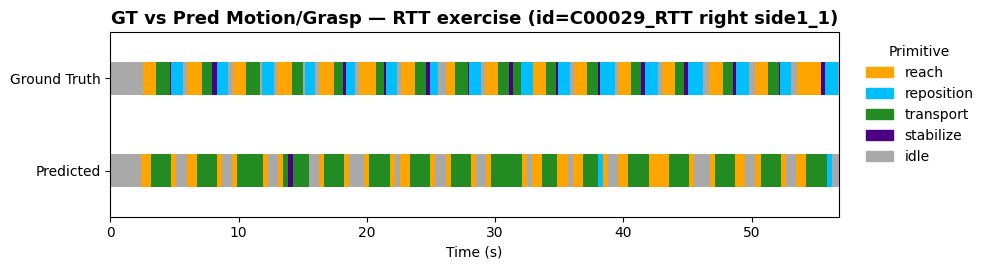

In [158]:
plot_motion_grasp_timeline(df_samples, activity_cleaned="RTT exercise")

Showing timeline for activity 'combing'  (id=C00028_combing1_1)


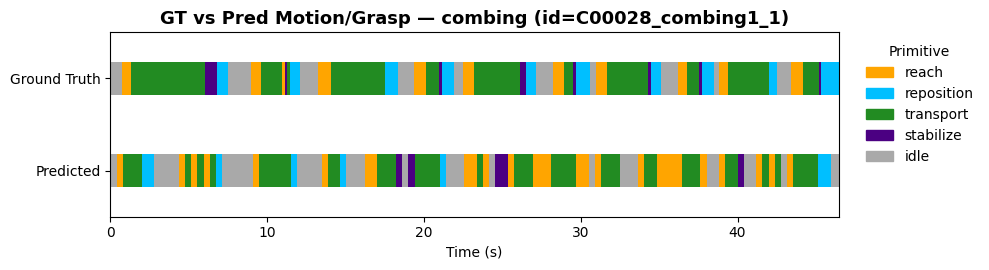

In [159]:
plot_motion_grasp_timeline(df_samples, activity_cleaned="combing")